#### Data science and AI Project
      Applying Kmean clustering analysis to :
        - identify high sales store.
        - identify high sales items families.
                                                                                                                                        Ahmed Dagash 

#### Import libraries :

In [25]:
import pandas as pd
from pandas import read_csv
import numpy as np
from matplotlib import pyplot
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import davies_bouldin_score

###     Data Exploration : 
        - Inspect data types
        - Summarize numerical features.
        - Analyze features .
        - Check for duplicates.
        - Visualize distributions.
        - check for patterns.
       

#### load Data File

In [28]:
train_sample = pd.read_csv(r"C:\Users\hp\Desktop\DS project\Ds initial data\train_sample.csv")

#### Data Shape :

In [30]:
train_sample.shape

(2000000, 13)

#### Data statistics :

In [32]:
train_sample.describe()

,id,store_nbr,item_nbr,unit_sales,onpromotion,day,month,dayofweek
count,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06
mean,9.999995e+05,2.332825e+01,7.672631e+02,8.551026e+00,5.483465e-01,1.389499e+01,1.394018e+00,3.046715e+00
std,5.773504e+05,1.377641e+01,4.638120e+02,1.965433e+01,4.976573e-01,8.232678e+00,4.886389e-01,2.006730e+00
min,0.000000e+00,1.000000e+00,0.000000e+00,-2.070000e+02,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
25%,4.999998e+05,1.000000e+01,3.660000e+02,2.000000e+00,0.000000e+00,7.000000e+00,1.000000e+00,1.000000e+00
50%,9.999995e+05,2.300000e+01,7.420000e+02,4.000000e+00,1.000000e+00,1.300000e+01,1.000000e+00,3.000000e+00
75%,1.499999e+06,3.600000e+01,1.165000e+03,9.000000e+00,1.000000e+00,1.900000e+01,2.000000e+00,5.000000e+00
max,1.999999e+06,5.400000e+01,1.624000e+03,7.001000e+03,1.000000e+00,3.100000e+01,2.000000e+00,6.000000e+00


In [33]:
train_sample.dtypes

id               int64
date            object
store_nbr        int64
item_nbr         int64
unit_sales     float64
onpromotion      int64
day              int64
month            int64
dayofweek        int64
family          object
city            object
state           object
type            object
dtype: object

#### Data first rows :

In [35]:
train_sample.head()

,id,date,store_nbr,item_nbr,unit_sales,onpromotion,day,month,dayofweek,family,city,state,type
0,0,2013-01-01,21,3,7.0,0,1,1,1,GROCERY I,Santo Domingo,Santo Domingo de los Tsachilas,B
1,1,2013-01-01,21,4,1.0,0,1,1,1,GROCERY I,Santo Domingo,Santo Domingo de los Tsachilas,B
2,2,2013-01-01,21,5,2.0,0,1,1,1,CLEANING,Santo Domingo,Santo Domingo de los Tsachilas,B
3,3,2013-01-01,21,12,1.0,0,1,1,1,GROCERY I,Santo Domingo,Santo Domingo de los Tsachilas,B
4,4,2013-01-01,21,15,1.0,0,1,1,1,BREAD/BAKERY,Santo Domingo,Santo Domingo de los Tsachilas,B


#### Data last rows :

In [37]:
train_sample.tail()

,id,date,store_nbr,item_nbr,unit_sales,onpromotion,day,month,dayofweek,family,city,state,type
1999995,1999995,2013-02-19,44,934,1.0,0,19,2,1,BEVERAGES,Quito,Pichincha,A
1999996,1999996,2013-02-19,44,936,1.0,0,19,2,1,GROCERY I,Quito,Pichincha,A
1999997,1999997,2013-02-19,44,937,5.0,0,19,2,1,GROCERY I,Quito,Pichincha,A
1999998,1999998,2013-02-19,44,939,15.0,0,19,2,1,BREAD/BAKERY,Quito,Pichincha,A
1999999,1999999,2013-02-19,44,940,11.0,0,19,2,1,CLEANING,Quito,Pichincha,A


#### Value counts :

In [39]:
for col in train_sample.columns:
    if train_sample[col].nunique() < 20:  # choose a threshold that fits your case
        print(f"\nValue counts for {col}:")
        print(train_sample[col].value_counts())



Value counts for onpromotion:
onpromotion
1    1096693
0     903307
Name: count, dtype: int64

Value counts for month:
month
1    1211964
2     788036
Name: count, dtype: int64

Value counts for dayofweek:
dayofweek
5    304340
6    293370
4    284219
2    282561
0    279929
1    278615
3    276966
Name: count, dtype: int64

Value counts for state:
state
Pichincha                         694980
Guayas                            369818
Azuay                             176003
Santo Domingo de los Tsachilas    133638
El Oro                            117325
Los Rios                           95980
Cotopaxi                           65544
Loja                               60707
Esmeraldas                         55729
Tungurahua                         46666
Bolivar                            44521
Pastaza                            37552
Imbabura                           35499
Chimborazo                         34503
Santa Elena                        28916
Manabi                     

#### check missing values :

In [41]:
train_sample.isnull().sum()

id             0
date           0
store_nbr      0
item_nbr       0
unit_sales     0
onpromotion    0
day            0
month          0
dayofweek      0
family         0
city           0
state          0
type           0
dtype: int64

#### Check duplicates :

In [43]:
train_sample.duplicated().sum()


0

In [44]:
train_sample['store_nbr'].nunique()

54

In [45]:
train_sample[train_sample['store_nbr'].duplicated()]


,id,date,store_nbr,item_nbr,unit_sales,onpromotion,day,month,dayofweek,family,city,state,type
1,1,2013-01-01,21,4,1.0,0,1,1,1,GROCERY I,Santo Domingo,Santo Domingo de los Tsachilas,B
2,2,2013-01-01,21,5,2.0,0,1,1,1,CLEANING,Santo Domingo,Santo Domingo de los Tsachilas,B
3,3,2013-01-01,21,12,1.0,0,1,1,1,GROCERY I,Santo Domingo,Santo Domingo de los Tsachilas,B
4,4,2013-01-01,21,15,1.0,0,1,1,1,BREAD/BAKERY,Santo Domingo,Santo Domingo de los Tsachilas,B
5,5,2013-01-01,21,16,3.0,1,1,1,1,GROCERY I,Santo Domingo,Santo Domingo de los Tsachilas,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1999995,1999995,2013-02-19,44,934,1.0,0,19,2,1,BEVERAGES,Quito,Pichincha,A
1999996,1999996,2013-02-19,44,936,1.0,0,19,2,1,GROCERY I,Quito,Pichincha,A
1999997,1999997,2013-02-19,44,937,5.0,0,19,2,1,GROCERY I,Quito,Pichincha,A
1999998,1999998,2013-02-19,44,939,15.0,0,19,2,1,BREAD/BAKERY,Quito,Pichincha,A


#### Dataset Columns 

In [47]:
train_sample.columns

Index(['id', 'date', 'store_nbr', 'item_nbr', 'unit_sales', 'onpromotion',
       'day', 'month', 'dayofweek', 'family', 'city', 'state', 'type'],
      dtype='object')

####  Sample from Data :

In [49]:
train_sample.sample(5)

,id,date,store_nbr,item_nbr,unit_sales,onpromotion,day,month,dayofweek,family,city,state,type
1429210,1429210,2013-02-06,3,363,3.000,0,6,2,2,HOME CARE,Quito,Pichincha,D
130091,130091,2013-01-05,7,38,30.000,1,5,1,5,PRODUCE,Quito,Pichincha,D
675392,675392,2013-01-18,37,1200,25.728,1,18,1,4,PRODUCE,Cuenca,Azuay,D
438876,438876,2013-01-12,40,1598,16.000,1,12,1,5,CLEANING,Machala,El Oro,C
1524067,1524067,2013-02-08,19,196,1.000,1,8,2,4,PRODUCE,Guaranda,Bolivar,C


#### Visualize data
      - Scatter plot.

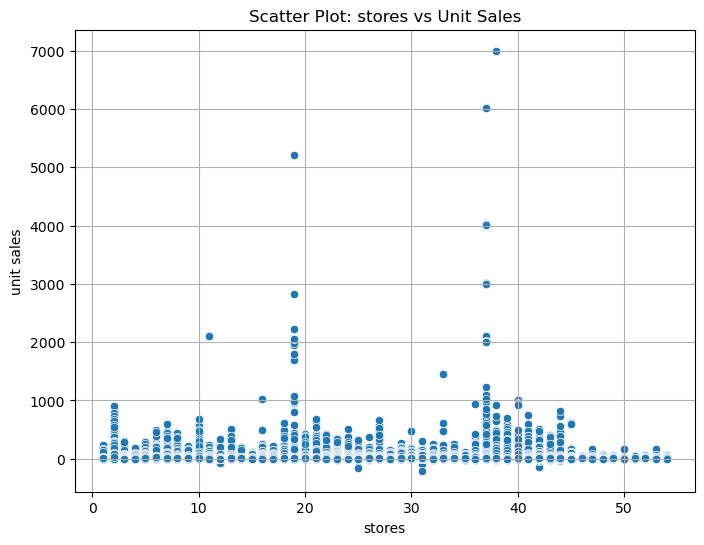

In [51]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=train_sample, x='store_nbr', y='unit_sales')
plt.title('Scatter Plot: stores vs Unit Sales')
plt.xlabel('stores')
plt.ylabel('unit sales')
plt.grid(True)
plt.show()


#### Visualize data:
      - histograms.

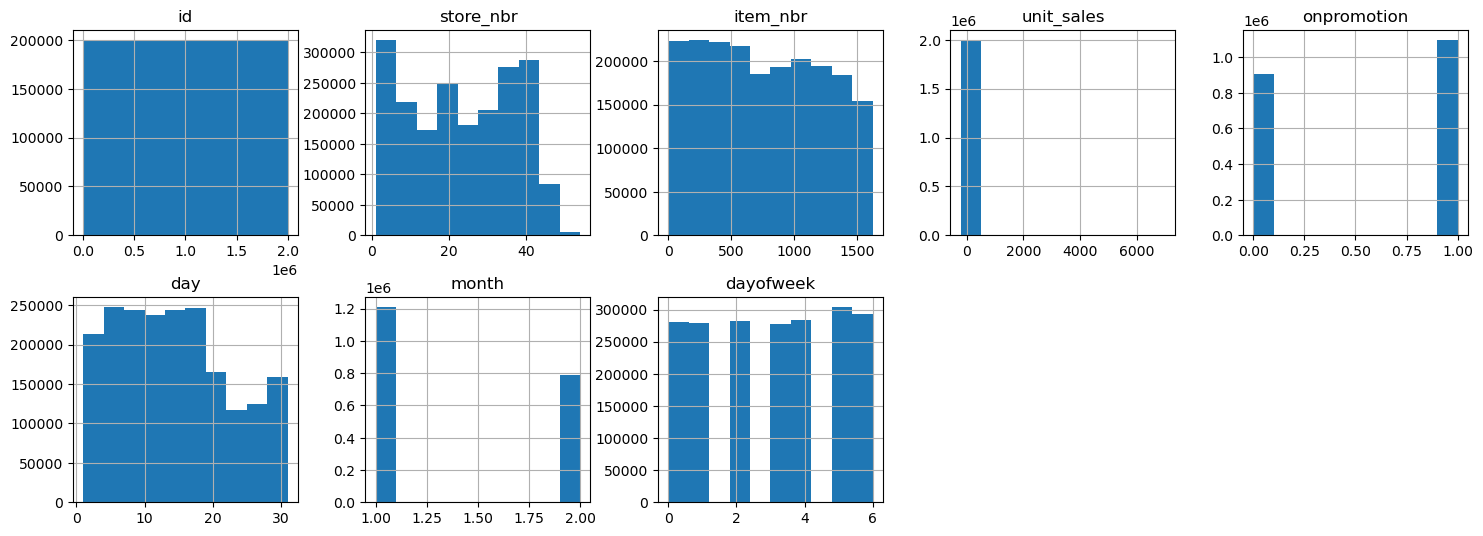

In [53]:
# histograms
train_sample.hist(figsize=(18,20),layout=(6,5),bins=10)
plt.show()

#### Visualize Data: 
      - Box plot.

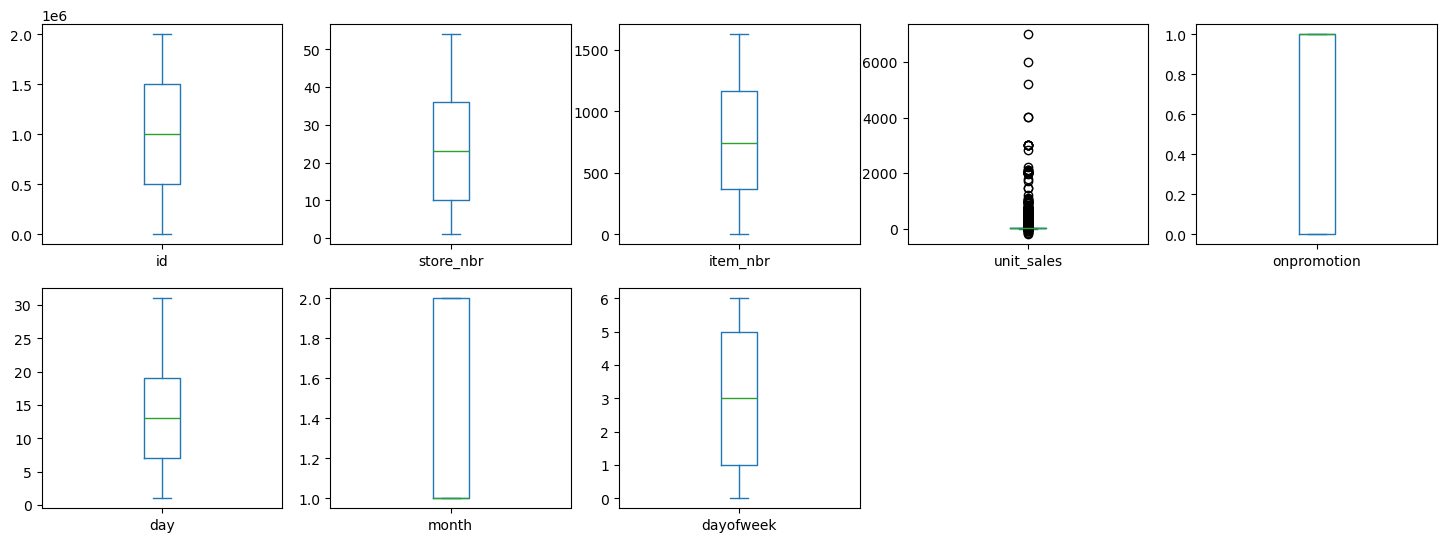

In [55]:
train_sample.plot(kind='box', subplots=True, layout=(6,5), figsize=(18,20), sharex=False, sharey=False)
pyplot.show()

#### Visualize Data:
      - Bar plot.

In [57]:
train_sample = train_sample[train_sample['unit_sales'] >= 0]


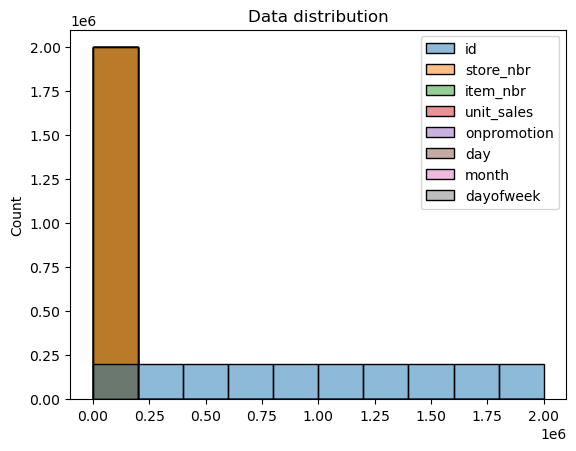

In [58]:
sns.histplot(train_sample, bins=10)
plt.title("Data distribution")
plt.show()



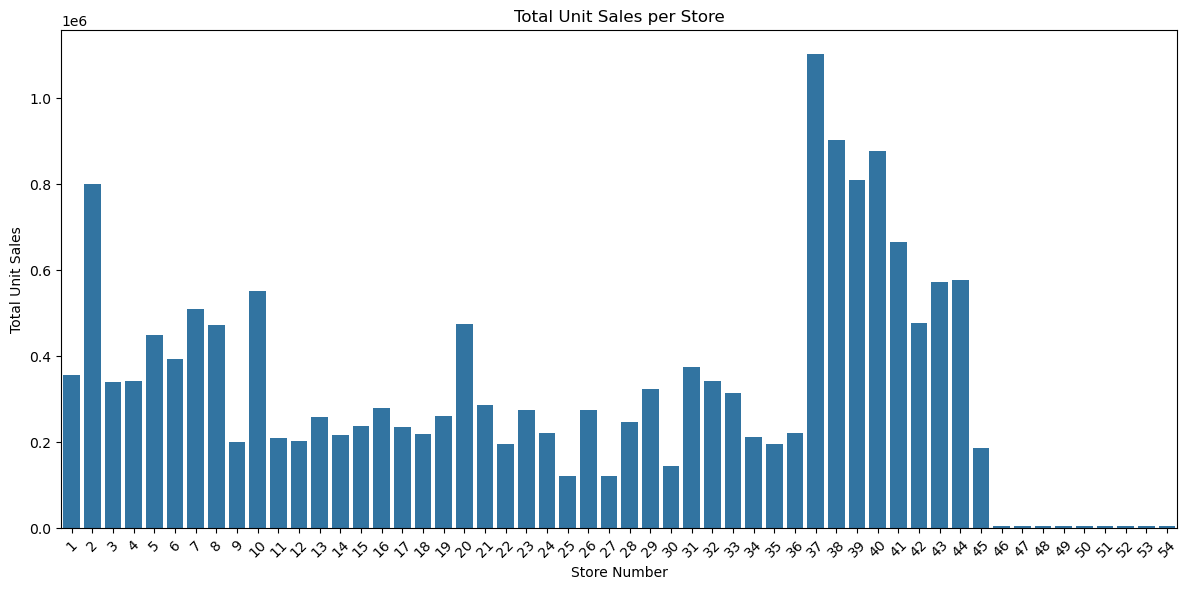

In [59]:
sales_by_store = train_sample.groupby('store_nbr')['unit_sales'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=sales_by_store, x='store_nbr', y='unit_sales')
plt.title("Total Unit Sales per Store")
plt.xlabel("Store Number")
plt.ylabel("Total Unit Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [60]:
train_sample = train_sample[train_sample['unit_sales'] >= 0]  # remove negatives


In [61]:
train_sample['log_sales'] = np.log1p(train_sample['unit_sales'])  # reduces right skew


#### Data exploration findings :
               
       - No missing values in numerical columns.
        
        - Negative unit_sales values (min = -207): likely returns or errors.
        
       - Extreme outliers in unit_sales (max = 7001).
        
       - High variance in sales across stores.
        
       - Categorical columns (type, state, city, family) need encoding.
               
       - onpromotion is binary and skewed toward value 1 (median = 1).
        
       - 54 unique stores observed across 2 million rows.
       
       - different  Data types.
        
        Visualizations:
        
        Histograms of all numeric features.
        
        Scatter plots (store_nbr vs unit_sales) : there are som simillar behavior
        
        Box plots for outlier detection: apperance off outliers.
        
        Bar plots showing aggregated sales.
        
        - Identification of key preprocessing needs:
        
                    - Outlier removal or handling.
                    
                    - Negative sales treatment.
                    
                    - Encoding for categorical data.
                    
                    - scale data for clustering.
                    
                    - feature engineering for stores to cluster.



#### Data preparation needs for modeling :
        A. Clean the Data
        B. Aggregate Data by store_nbr
        C. Add Store Metadata
        D. Encode Categorical Features
        E. Scale Numerical Features
        f. scale data

#### take a copy from dataset :

In [65]:
train_model = train_sample.copy()

#### remove negative values

In [67]:
train_model = train_model[train_model['unit_sales'] >= 0].copy()

#### Convert date to datetime format

In [69]:
train_model['date'] = pd.to_datetime(train_model['date'])


####  Drop Unnecessary Columns

In [71]:
train_model.drop(columns=['id'], inplace=True)


#### Convert Categorical Columns to Category Type
This helps save memory and prepares for encoding later:

In [73]:
# List of known categorical columns
cat_cols = ['family', 'city', 'state', 'type']

# Convert them to category dtype
for col in cat_cols:
    train_model[col] = train_model[col].astype('category')


#### Verify the Result

In [75]:
train_model.dtypes


date           datetime64[ns]
store_nbr               int64
item_nbr                int64
unit_sales            float64
onpromotion             int64
day                     int64
month                   int64
dayofweek               int64
family               category
city                 category
state                category
type                 category
log_sales             float64
dtype: object

##### write comments 

#### Encode Categorical Variables for Clustering :
   one-hot encoding 

In [78]:
# Select categorical columns to encode
categorical_cols = ['family', 'city', 'state', 'type']

# Apply one-hot encoding
train_encoded = pd.get_dummies(train_model, columns=categorical_cols, drop_first=True)


In [79]:
train_encoded.columns  # Shows all the new one-hot encoded columns


Index(['date', 'store_nbr', 'item_nbr', 'unit_sales', 'onpromotion', 'day',
       'month', 'dayofweek', 'log_sales', 'family_BABY CARE', 'family_BEAUTY',
       'family_BEVERAGES', 'family_BOOKS', 'family_BREAD/BAKERY',
       'family_CELEBRATION', 'family_CLEANING', 'family_DAIRY', 'family_DELI',
       'family_EGGS', 'family_FROZEN FOODS', 'family_GROCERY I',
       'family_GROCERY II', 'family_HARDWARE', 'family_HOME AND KITCHEN I',
       'family_HOME AND KITCHEN II', 'family_HOME APPLIANCES',
       'family_HOME CARE', 'family_LADIESWEAR', 'family_LAWN AND GARDEN',
       'family_LINGERIE', 'family_LIQUOR,WINE,BEER', 'family_MAGAZINES',
       'family_MEATS', 'family_PERSONAL CARE', 'family_PET SUPPLIES',
       'family_PLAYERS AND ELECTRONICS', 'family_POULTRY',
       'family_PREPARED FOODS', 'family_PRODUCE',
       'family_SCHOOL AND OFFICE SUPPLIES', 'family_SEAFOOD', 'city_Babahoyo',
       'city_Cayambe', 'city_Cuenca', 'city_Daule', 'city_El Carmen',
       'city_Esmerald

In [80]:
train_encoded.head()

,date,store_nbr,item_nbr,unit_sales,onpromotion,day,month,dayofweek,log_sales,family_BABY CARE,...,state_Manabi,state_Pastaza,state_Pichincha,state_Santa Elena,state_Santo Domingo de los Tsachilas,state_Tungurahua,type_B,type_C,type_D,type_E
0,2013-01-01,21,3,7.0,0,1,1,1,2.079442,False,...,False,False,False,False,True,False,True,False,False,False
1,2013-01-01,21,4,1.0,0,1,1,1,0.693147,False,...,False,False,False,False,True,False,True,False,False,False
2,2013-01-01,21,5,2.0,0,1,1,1,1.098612,False,...,False,False,False,False,True,False,True,False,False,False
3,2013-01-01,21,12,1.0,0,1,1,1,0.693147,False,...,False,False,False,False,True,False,True,False,False,False
4,2013-01-01,21,15,1.0,0,1,1,1,0.693147,False,...,False,False,False,False,True,False,True,False,False,False


####  Aggregate sales data at the store level
     create summary features per store that capture sales patterns.
    
    Typical features  include:
    
    Total sales per store
    
    Average daily sales per store
    
    Sales variance (volatility)
    
    Proportion of sales on promotion
    
   

####  aggregate total and average sales per store:

In [83]:
import pandas as pd

# Suppose your dataframe is called train_encoded
# 1. Total sales per store
total_sales = train_encoded.groupby('store_nbr')['unit_sales'].sum().rename('total_sales')

# 2. Average daily sales per store
avg_daily_sales =train_encoded.groupby('store_nbr')['unit_sales'].mean().rename('avg_daily_sales')

# 3. Sales variance (volatility) per store
sales_variance = train_encoded.groupby('store_nbr')['unit_sales'].var().fillna(0).rename('sales_variance')

# 4. Proportion of sales on promotion per store
prop_promo = train_encoded.groupby('store_nbr')['onpromotion'].mean().rename('prop_sales_on_promo')

# Combine all features into one dataframe
store_features = pd.concat([total_sales, avg_daily_sales, sales_variance, prop_promo], axis=1).reset_index()


In [84]:
store_features.head()

,store_nbr,total_sales,avg_daily_sales,sales_variance,prop_sales_on_promo
0,1,357529.909,6.793659,99.020144,0.495696
1,2,800962.206,13.448892,471.674879,0.492864
2,3,340260.155,6.664058,92.216195,0.484851
3,4,342638.563,6.756558,85.939235,0.488563
4,5,450421.320,8.169130,130.793782,0.486425


#### feature engineering for modeling  :

 #### Capture weekly sales patterns (avg sales per day of week)

In [87]:
# Average sales per day of week per store
weekly_pattern =train_encoded.groupby(['store_nbr', 'dayofweek'])['unit_sales'].mean().unstack(fill_value=0)

# Rename columns for clarity
weekly_pattern.columns = [f'avg_sales_dayofweek_{col}' for col in weekly_pattern.columns]

# Merge with store_features
store_features = store_features.merge(weekly_pattern, on='store_nbr')


 #### Capture monthly sales patterns (avg sales per month)

In [89]:
# Average sales per month per store
monthly_pattern = train_encoded.groupby(['store_nbr', 'month'])['unit_sales'].mean().unstack(fill_value=0)

monthly_pattern.columns = [f'avg_sales_month_{col}' for col in monthly_pattern.columns]

store_features = store_features.merge(monthly_pattern, on='store_nbr')


In [90]:
store_features.head()

,store_nbr,total_sales,avg_daily_sales,sales_variance,prop_sales_on_promo,avg_sales_dayofweek_0,avg_sales_dayofweek_1,avg_sales_dayofweek_2,avg_sales_dayofweek_3,avg_sales_dayofweek_4,avg_sales_dayofweek_5,avg_sales_dayofweek_6,avg_sales_month_1,avg_sales_month_2
0,1,357529.909,6.793659,99.020144,0.495696,6.234372,5.839367,6.772761,5.767699,6.725699,7.931352,8.093868,6.885966,6.649483
1,2,800962.206,13.448892,471.674879,0.492864,12.261592,11.390337,13.195450,11.141351,12.690506,16.524231,16.720015,13.786929,12.924259
2,3,340260.155,6.664058,92.216195,0.484851,5.836488,5.839590,6.575670,5.285759,6.284763,7.805664,8.743036,6.831458,6.403389
3,4,342638.563,6.756558,85.939235,0.488563,6.393770,5.935285,6.867804,6.236956,6.546046,7.409560,7.817098,6.796489,6.694444
4,5,450421.320,8.169130,130.793782,0.486425,7.304458,6.876800,7.992529,6.446222,7.050738,9.828419,11.351920,8.356425,7.878505


In [91]:
store_features.shape

(54, 14)

#### Scale/normalize features

In [93]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
features_to_scale = store_features.columns.difference(['store_nbr'])

store_features_scaled = store_features.copy()
store_features_scaled[features_to_scale] = scaler.fit_transform(store_features[features_to_scale])


In [94]:
store_features_scaled.shape

(54, 14)

In [95]:
store_features_scaled.describe()

,store_nbr,total_sales,avg_daily_sales,sales_variance,prop_sales_on_promo,avg_sales_dayofweek_0,avg_sales_dayofweek_1,avg_sales_dayofweek_2,avg_sales_dayofweek_3,avg_sales_dayofweek_4,avg_sales_dayofweek_5,avg_sales_dayofweek_6,avg_sales_month_1,avg_sales_month_2
count,54.000000,5.400000e+01,5.400000e+01,5.400000e+01,5.400000e+01,5.400000e+01,5.400000e+01,5.400000e+01,5.400000e+01,5.400000e+01,5.400000e+01,5.400000e+01,5.400000e+01,5.400000e+01
mean,27.500000,-8.635068e-17,5.551115e-17,3.083953e-18,7.278129e-16,-6.579099e-17,-2.035409e-16,1.058824e-16,3.659624e-16,-8.635068e-17,4.338094e-16,2.467162e-16,-3.803542e-16,-2.364364e-16
std,15.732133,1.009390e+00,1.009390e+00,1.009390e+00,1.009390e+00,1.009390e+00,1.009390e+00,1.009390e+00,1.009390e+00,1.009390e+00,1.009390e+00,1.009390e+00,1.009390e+00,1.009390e+00
min,1.000000,-1.254027e+00,-1.160784e+00,-4.616916e-01,-1.970299e+00,-1.258256e+00,-1.250824e+00,-1.344538e+00,-1.212786e+00,-1.271427e+00,-1.056847e+00,-1.283104e+00,-1.141514e+00,-1.167425e+00
25%,14.250000,-4.842069e-01,-7.017111e-01,-3.679402e-01,-8.898619e-01,-5.890154e-01,-6.062024e-01,-5.397285e-01,-6.516267e-01,-6.329254e-01,-6.910231e-01,-5.421518e-01,-6.246202e-01,-7.169887e-01
50%,27.500000,-2.315228e-01,-2.769949e-01,-3.075517e-01,1.549777e-01,-2.790052e-01,-2.125300e-01,-3.412024e-01,-2.843720e-01,-2.755451e-01,-3.180205e-01,-2.639656e-01,-3.065669e-01,-2.848576e-01
75%,40.750000,4.790181e-01,1.664609e-01,-1.048328e-01,7.628572e-01,3.313854e-01,2.085110e-01,1.823655e-01,2.254474e-01,2.634296e-01,2.770299e-01,1.328003e-01,2.238748e-01,2.636890e-01
max,54.000000,3.154618e+00,3.479522e+00,6.157723e+00,1.852005e+00,3.048110e+00,4.325099e+00,3.442763e+00,3.954319e+00,3.288684e+00,3.271158e+00,2.849619e+00,3.545801e+00,3.319188e+00


#### Data PREPARATION RESULTS FOR MODELING :
        - data now clean and no missing values and no negative values
        - all categorical data types was one-hot encoded
        - data was scaled 
        - data ready for applying kmean clustering
        

#### Modeling : Apply Kmean clustering  
         - Choose the number of clusters (K)
         - fit Kmean 
         - evaluate kmean 
         - analyze clusters
         - findings

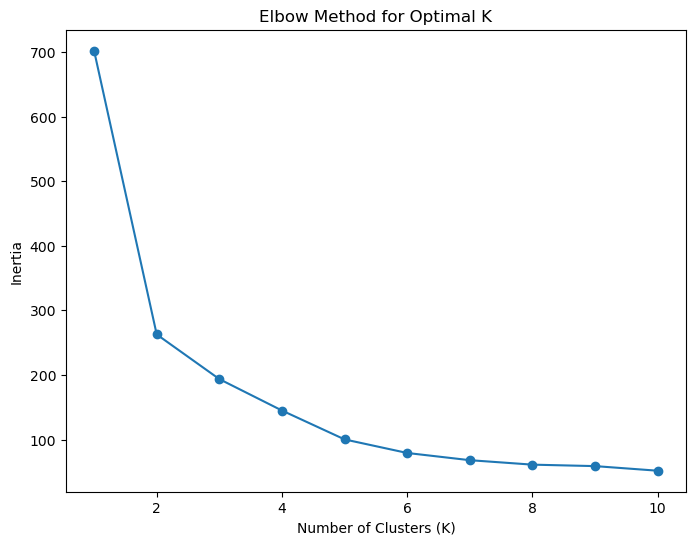

In [98]:
# Try different numbers of clusters (K) and calculate inertia
inertia = []
k_range = range(1, 11)  # Let's test K values from 1 to 10

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(store_features_scaled[features_to_scale])  # Use the scaled features for clustering
    inertia.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(8, 6))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.show()


#### Fit KMeans with the chosen number of clusters

In [100]:
# Let's assume we chose K=2 from the Elbow method
kmeans = KMeans(n_clusters=2, random_state=42)

# Fit the model
store_features_scaled['cluster'] = kmeans.fit_predict(store_features_scaled[features_to_scale])

# Add the cluster labels to the original dataframe


#### Visualize the clustering results

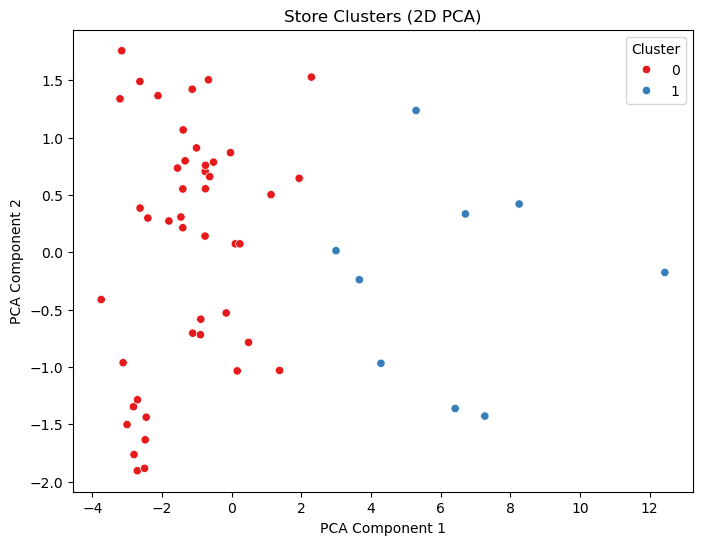

In [102]:
from sklearn.decomposition import PCA

# Apply PCA to reduce the dimensionality to 2D
pca = PCA(n_components=2)
pca_components = pca.fit_transform(store_features_scaled[features_to_scale])

# Create a scatter plot of the clusters in 2D
plt.figure(figsize=(8, 6))
sns.scatterplot(x=pca_components[:, 0], y=pca_components[:, 1], hue=store_features_scaled['cluster'], palette='Set1')
plt.title('Store Clusters (2D PCA)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')
plt.show()


#### Number of stores in each cluster:

In [104]:
# Count the number of stores in each cluster
cluster_counts = store_features_scaled['cluster'].value_counts()
print("Stores per cluster:")
print(cluster_counts)


Stores per cluster:
cluster
0    45
1     9
Name: count, dtype: int64


In [105]:
# Example: if you still have original store_features with sales columns
store_features['cluster'] = store_features_scaled['cluster']

# Now group by cluster and compare sales-related metrics
cluster_summary = store_features.groupby('cluster')[[
    'total_sales', 'avg_daily_sales', 'sales_variance', 'prop_sales_on_promo'
]].mean().reset_index()

print(cluster_summary)


   cluster    total_sales  avg_daily_sales  sales_variance  \
0        0  227568.172489         6.447536      148.066054   
1        1  762560.622444        13.271359      924.606541   

   prop_sales_on_promo  
0             0.533028  
1             0.547436  


#####     🎯 Key Business Insights
    ✅ Cluster 1: High-Sales Stores
    Much higher total and daily sales
    
    Slightly more promotion-sensitive
    
    High variance → Could mean they handle peak sales or volatile demand
    
    These are your top-performing stores — candidates for:
    
    Expansion strategies
    
    High inventory stocking
    
    Targeted marketing or VIP pricing
    
    ✅ Cluster 0: Low-to-Mid Performing Stores
    Lower and more stable sales
    
    Possibly mature or smaller market locations
    
    Useful for:
    
    Efficiency optimization
    
    Cost reduction
    
    Testing smaller-scale promotions
    


####  Label and Save Clustered Store Data

In [108]:
store_features['cluster'] = store_features_scaled['cluster']
store_features.to_csv("clustered_stores.csv", index=False)


####  Visualize Cluster Geography or Store Types 

### Check what columns are available

In [111]:
print(store_features.columns)


Index(['store_nbr', 'total_sales', 'avg_daily_sales', 'sales_variance',
       'prop_sales_on_promo', 'avg_sales_dayofweek_0', 'avg_sales_dayofweek_1',
       'avg_sales_dayofweek_2', 'avg_sales_dayofweek_3',
       'avg_sales_dayofweek_4', 'avg_sales_dayofweek_5',
       'avg_sales_dayofweek_6', 'avg_sales_month_1', 'avg_sales_month_2',
       'cluster'],
      dtype='object')


#### Merge back the metadata

In [113]:
# Create a store-to-state mapping from the original dataset
store_meta = train_sample.drop_duplicates('store_nbr')[['store_nbr', 'state', 'city', 'type']]

# Merge it back into your clustered DataFrame
store_features = store_features.merge(store_meta, on='store_nbr', how='left')


In [114]:
# Create a store-to-state mapping from the original dataset
store_meta = train_sample.drop_duplicates('store_nbr')[['store_nbr', 'state', 'city', 'type']]

# Merge it back into your clustered DataFrame
store_features = store_features.merge(store_meta, on='store_nbr', how='left')


#### See Which Cluster Belongs to Which State


In [116]:
print(store_features.columns)


Index(['store_nbr', 'total_sales', 'avg_daily_sales', 'sales_variance',
       'prop_sales_on_promo', 'avg_sales_dayofweek_0', 'avg_sales_dayofweek_1',
       'avg_sales_dayofweek_2', 'avg_sales_dayofweek_3',
       'avg_sales_dayofweek_4', 'avg_sales_dayofweek_5',
       'avg_sales_dayofweek_6', 'avg_sales_month_1', 'avg_sales_month_2',
       'cluster', 'state_x', 'city_x', 'type_x', 'state_y', 'city_y',
       'type_y'],
      dtype='object')


#### Rename state_y → state (and same for city/type)

In [118]:
store_features.rename(columns={
    'state_y': 'state',
    'city_y': 'city',
    'type_y': 'type'
}, inplace=True)


#### You can now safely drop the _x versions if not needed:

In [120]:
store_features.drop(columns=['state_x', 'city_x', 'type_x'], inplace=True)


#### Now Group by Cluster and State

In [122]:
cluster_state_counts = store_features.groupby(['cluster', 'state']).size().reset_index(name='store_count')
print(cluster_state_counts)


    cluster                           state  store_count
0         0                           Azuay            1
1         0                         Bolivar            1
2         0                      Chimborazo            1
3         0                        Cotopaxi            2
4         0                          Guayas           11
5         0                        Imbabura            1
6         0                        Los Rios            2
7         0                          Manabi            3
8         0                         Pastaza            1
9         0                       Pichincha           16
10        0                     Santa Elena            1
11        0  Santo Domingo de los Tsachilas            3
12        0                      Tungurahua            2
13        1                           Azuay            2
14        1                          El Oro            2
15        1                      Esmeraldas            1
16        1                    

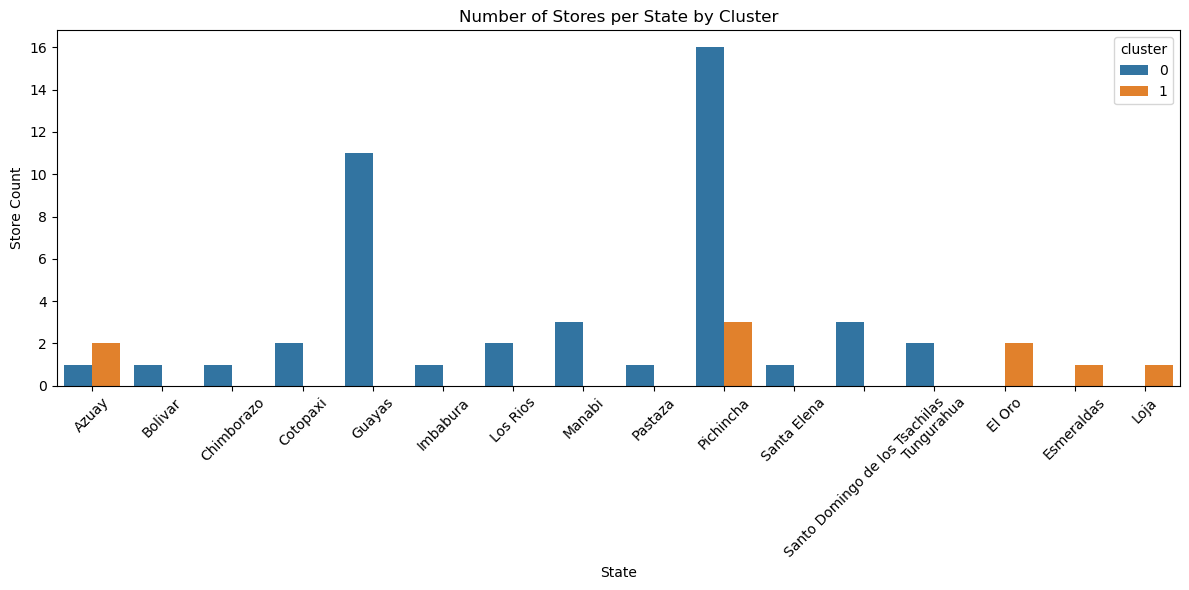

In [123]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.barplot(data=cluster_state_counts, x='state', y='store_count', hue='cluster')
plt.title("Number of Stores per State by Cluster")
plt.xlabel("State")
plt.ylabel("Store Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### A table or chart showing which states have the most stores in Cluster 1 (high-performing), helping you target expansion or investment more accurately.

####  View Cities in Cluster 1

#### Filter for Cluster 1

In [127]:
cluster_1_stores = store_features[store_features['cluster'] == 1]


#### Count Cities in Cluster 1

In [129]:
city_counts = cluster_1_stores['city'].value_counts()
print(city_counts)


city
Quito         3
Cuenca        2
Machala       2
Loja          1
Esmeraldas    1
Name: count, dtype: int64


#### Display as a Bar Chart

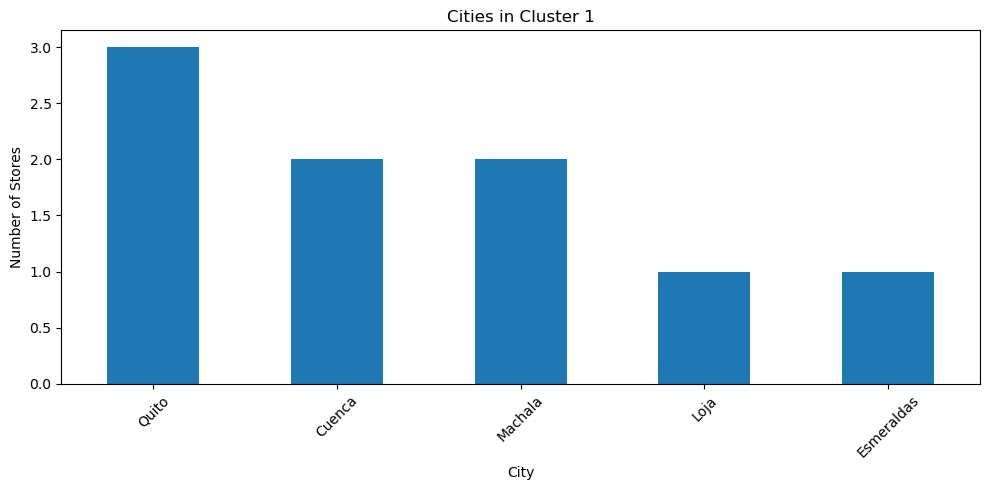

In [131]:
import matplotlib.pyplot as plt

city_counts.plot(kind='bar', figsize=(10, 5), title='Cities in Cluster 1')
plt.xlabel('City')
plt.ylabel('Number of Stores')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### Business Insights:
    🔹 1. Quito is the top-performing city in Cluster 1:
    It has the highest number of high-performing stores.
    
    Strong candidate for expanding store network, marketing, or inventory investment.
    
    🔹 2. Cuenca and Machala also show consistent demand:
    Each has 2 stores in the high-sales cluster.
    
    Indicates stable market potential beyond the capital.
    
    🔹 3. Loja and Esmeraldas:
    Smaller representation, but they still made it into the high-performing cluster — might be regional sales leaders or untapped potential.



#### 2- cluster Items based on sales:
    -Aggregate Per item_nbr

In [135]:
# Identify relevant numerical features
numeric_cols = ['unit_sales', 'log_sales', 'onpromotion', 'day', 'month', 'dayofweek']

# Optional: add family one-hot columns
family_cols = [col for col in train_encoded.columns if col.startswith('family_')]

# Group by item
item_features = train_encoded.groupby('item_nbr')[numeric_cols + family_cols].agg(['mean', 'std', 'sum'])

# Flatten MultiIndex columns
item_features.columns = ['_'.join(col) for col in item_features.columns]
item_features.reset_index(inplace=True)


####  Add Store Coverage

In [137]:
item_store_coverage = train_encoded.groupby('item_nbr')['store_nbr'].nunique().reset_index()
item_store_coverage.rename(columns={'store_nbr': 'num_stores'}, inplace=True)

# Merge with aggregated features
item_features = item_features.merge(item_store_coverage, on='item_nbr')


#### check for missing values 

In [139]:
item_features.isnull().sum()


item_nbr                                 0
unit_sales_mean                          0
unit_sales_std                           1
unit_sales_sum                           0
log_sales_mean                           0
                                        ..
family_SCHOOL AND OFFICE SUPPLIES_sum    0
family_SEAFOOD_mean                      0
family_SEAFOOD_std                       1
family_SEAFOOD_sum                       0
num_stores                               0
Length: 116, dtype: int64

####  Fill missing values

In [141]:
item_features =item_features.fillna(0)  # or use mean: X_items = X_items.fillna(X_items.mean())


In [142]:
item_features.describe()

,item_nbr,unit_sales_mean,unit_sales_std,unit_sales_sum,log_sales_mean,log_sales_std,log_sales_sum,onpromotion_mean,onpromotion_std,onpromotion_sum,...,family_PRODUCE_mean,family_PRODUCE_std,family_PRODUCE_sum,family_SCHOOL AND OFFICE SUPPLIES_mean,family_SCHOOL AND OFFICE SUPPLIES_std,family_SCHOOL AND OFFICE SUPPLIES_sum,family_SEAFOOD_mean,family_SEAFOOD_std,family_SEAFOOD_sum,num_stores
count,1625.000000,1625.000000,1625.000000,1625.000000,1625.000000,1625.000000,1625.000000,1625.000000,1625.000000,1625.000000,...,1625.000000,1625.000000,1625.000000,1625.000000,1625.000000,1625.000000,1625.000000,1625.000000,1625.000000,1625.000000
mean,812.000000,8.007565,8.573301,10525.300532,1.705845,0.655379,2195.014172,0.544456,0.332473,674.844308,...,0.074686,0.262235,91.871385,0.003687,0.056886,4.501538,0.001917,0.038211,2.401846,39.667077
std,469.241409,11.519249,18.931803,14102.140670,0.538791,0.165755,1380.042185,0.333012,0.163856,557.770403,...,0.010119,0.018638,41.608190,0.002760,0.020935,2.905346,0.001519,0.021282,1.929259,11.096389
min,0.000000,1.000000,0.000000,1.000000,0.693147,0.000000,0.693147,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,406.000000,3.551881,3.108753,3645.000000,1.339168,0.549842,1255.264045,0.162486,0.206567,144.000000,...,0.070068,0.255348,63.000000,0.002410,0.049044,2.000000,0.000897,0.029941,1.000000,35.000000
50%,812.000000,5.485116,5.116266,6613.000000,1.633016,0.656652,1942.069182,0.682454,0.412119,612.000000,...,0.074388,0.262512,88.000000,0.003504,0.059101,4.000000,0.001802,0.042428,2.000000,43.000000
75%,1218.000000,8.543455,8.377176,11355.000000,1.946475,0.754292,2872.640410,0.771348,0.461994,1071.000000,...,0.079128,0.270104,125.000000,0.004739,0.068703,6.000000,0.002732,0.052228,4.000000,48.000000
max,1624.000000,292.659709,562.070590,173747.000000,4.753214,1.397414,8901.302610,1.000000,0.502083,2244.000000,...,0.250000,0.462910,191.000000,0.076923,0.277350,16.000000,0.013216,0.114450,11.000000,54.000000


#### scale

In [144]:
item_feature_scaled = StandardScaler().fit_transform(item_features)

#### run kmean
   find k

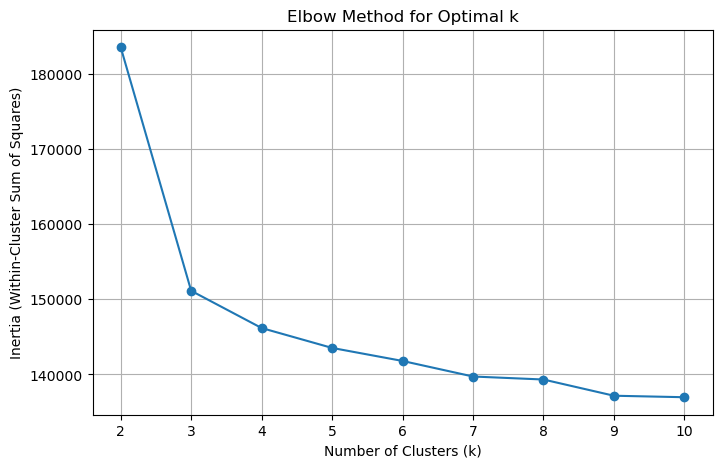

In [146]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertias = []
k_range = range(2, 11)  # You can extend to 15 or more if needed

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(item_feature_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.grid(True)
plt.show()


In [149]:
kmeans = KMeans(n_clusters=3, random_state=42)
item_features['cluster'] = kmeans.fit_predict(item_feature_scaled)

#### Visualize with PCA

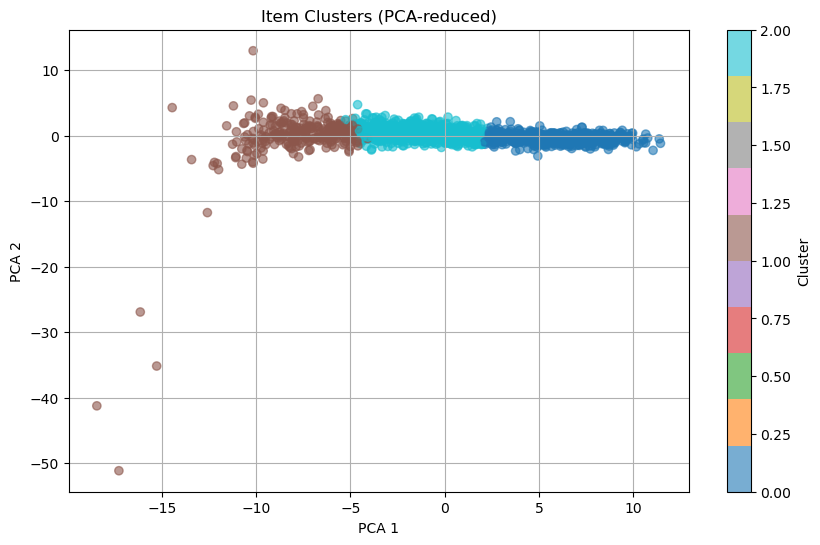

In [151]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
item_pca = pca.fit_transform(item_feature_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(item_pca[:, 0], item_pca[:, 1], c=item_features['cluster'], cmap='tab10', alpha=0.6)
plt.title("Item Clusters (PCA-reduced)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()


 #### Analyze Clusters by Sales Behavior

In [153]:
item_features.groupby('cluster')[['unit_sales_mean', 'unit_sales_sum', 'onpromotion_mean']].mean()


,unit_sales_mean,unit_sales_sum,onpromotion_mean
cluster,,,
0,9.660666,18973.214616,0.577270
1,7.264437,2300.007633,0.594308
2,7.150756,7698.041019,0.504813


####  The Best Cluster:
    Cluster 0 has:
    
    The highest average sales
    
    The highest total sales
    
    And a solid promotion rate
    
    So Cluster 0 is your top-performing item group, ideal for templates, expansion, or featuring in campaigns.

In [155]:
item_features['cluster'].value_counts()


cluster
2    802
0    542
1    281
Name: count, dtype: int64

####  Filter Items in Cluster 0

In [157]:
top_items_cluster_0 = item_features[item_features['cluster'] == 0]


In [237]:
# Merge item_features (which has 'item_nbr' and 'cluster') with items_data
item_features_with_family = item_features.merge(train_sample[['item_nbr', 'family']], on='item_nbr', how='left')


In [239]:
# Filter cluster 0
cluster_0_items = item_features_with_family[item_features_with_family['cluster'] == 0]

# Count families
cluster_0_family_counts = cluster_0_items['family'].value_counts()
print(cluster_0_family_counts)


family
GROCERY I                     330490
BEVERAGES                     151392
CLEANING                      110921
PRODUCE                        75427
DAIRY                          59631
PERSONAL CARE                  37865
BREAD/BAKERY                   33140
HOME CARE                      27005
DELI                           22693
MEATS                          20826
HOME AND KITCHEN I             19169
LIQUOR,WINE,BEER               18262
FROZEN FOODS                   13725
POULTRY                        13288
HOME AND KITCHEN II            11212
EGGS                           10291
CELEBRATION                     7579
PREPARED FOODS                  6533
LAWN AND GARDEN                 6459
LADIESWEAR                      5219
AUTOMOTIVE                      4919
LINGERIE                        4876
BEAUTY                          4620
PLAYERS AND ELECTRONICS         4169
SCHOOL AND OFFICE SUPPLIES      3738
GROCERY II                      3508
PET SUPPLIES                   

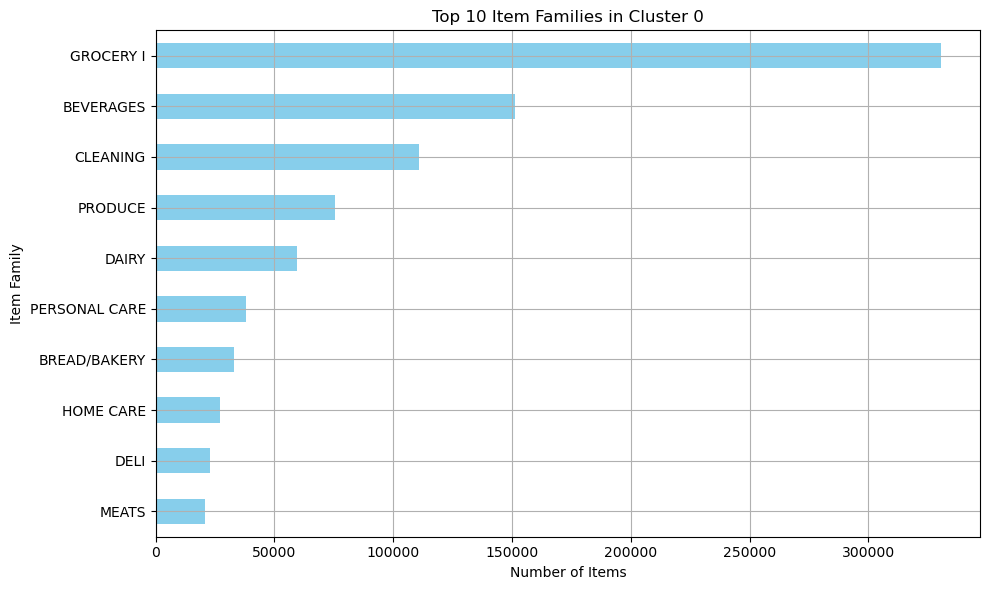

In [241]:
import matplotlib.pyplot as plt

# Plot top 10 families in cluster 0
cluster_0_family_counts.head(10).plot(kind='barh', figsize=(10, 6), color='skyblue')
plt.title('Top 10 Item Families in Cluster 0')
plt.xlabel('Number of Items')
plt.ylabel('Item Family')
plt.gca().invert_yaxis()
plt.grid(True)
plt.tight_layout()
plt.show()


#### key findings :
 Cluster 0 (high sales) mostly consists of items from:

    GROCERY I → 330,490 items
    
    BEVERAGES → 151,392 items
    
    CLEANING → 110,921 items

#### business Insights :

    1. Leverage High-Performing Stores as Expansion
    Templates
    Analyze stores in Cluster 1, which demonstrated the
    highest total and average sales performance, and
    identify the key characteristics that contributed to their
    success:
    Location attributes (e.g., proximity to dense
    residential or commercial areas)
    Services offered (e.g., in-store promotions, loyalty
    programs, product variety)
    Staffing levels and training quality
    Store layout and design (e.g., clean, spacious, well-lit,
    intuitive navigation)
    Working hours (e.g., extended or optimized for local
    demand)
    Compensation and incentives (e.g., higher salaries
    linked to staff performance)
    Recommendation: Use these high-performing stores
    as operational templates when opening new stores in
    target markets.
    2. Support Low-Performing Stores with Resources and Training
    Stores in Cluster 0 showed lower sales and more stable patterns.
    To boost their performance:
    Conduct store audits to identify gaps in customer service,
    layout, or stock availability
    Provide additional training for staff on customer interaction
    and upselling
    Invest in local marketing efforts and improve visibility
    Offer infrastructure improvements where necessary
    (e.g., lighting, signage, or shelving)
    Recommendation: Equip underperforming stores with
    tailored support packages, knowledge-sharing from Cluster 1,
    and localized promotions to stimulate demand.
##### Items 
    3. Prioritize High-Sales Product Families in New Markets
    Items in Cluster 0 product families include:
    GROCERY I
    CLEANING
    BEVERAGES
    Recommendation: Stock these families as the core product range when launching in new markets, as
    they are proven to generate high and consistent demand.
    4. Stimulate Sales of Other Product Families through Promotions
    Families that underperformed in sales can still be valuable but may need customer incentive:
    Introduce bundled promotions with high-performing items
    Offer limited-time discounts or loyalty program points
    Highlight underexposed products through in-store displays and digital marketing
    Recommendation: Apply strategic discounts and promotional campaigns to increase visibility and sales for items
    in low-performing clusters or families.
    5. Create a Standardized Expansion Toolkit:
    Combine the findings from both store and item cluster analyses into a repeatable toolkit for launching
    new locations. This should include:
    A high-performance store blueprint, A core product list from top-selling families
    Staffing models and scheduling templates
    Marketing and promotion playbooks for new locations
    Recommendation: Formalize these insights into a documented expansion guide to ensure consistency,
    efficiency, and faster time-to-market when entering new regions.
